# BOOKING human-only Isolation Forest (v1)

- Trains an Isolation Forest **only** on `type==BOOKING` and `label==ALLOW` rows from one or more JSONL files.
- Saves artifacts to `../model_joblib/isoforest_booking_v1/booking/`:
  - `model.joblib`
  - `meta.json` (includes feature list + chosen anomaly threshold)
  - `input_features.json`

Notes:
- This model is intended as a **2nd-stage** filter for the BOOKING review band ("is this sample non-human-like?").
- Threshold is set to keep a very low false-positive rate on the human training set (configurable via `TARGET_FP_RATE`).


In [1]:
import json
import time
from dataclasses import asdict
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

args = SimpleNamespace(
    RUN_VERSION="isoforest_booking_v1",
    # One or more JSONL files (or directories). If directory is provided, all *.jsonl under it are loaded.
    JSONL_INPUTS=[
        # r"C:\\path\\to\\train.jsonl",
        # r"C:\\path\\to\\jsonl_dir",
        r"C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\data\train_human_final\train_human_final.jsonl"
    ],
    TARGET_TYPE="BOOKING",
    TRAIN_LABEL="ALLOW",
    MODEL_SAVE_DIR=Path("../model_joblib") / "isoforest_booking_v1" / "booking",
    RANDOM_STATE=42,
    # IsolationForest params
    N_ESTIMATORS=600,
    MAX_SAMPLES="auto",
    MAX_FEATURES=1.0,
    BOOTSTRAP=False,
    N_JOBS=-1,
    # Threshold selection: keep this false-positive rate on human training set
    TARGET_FP_RATE=0.001,
)
args

namespace(RUN_VERSION='isoforest_booking_v1',
          JSONL_INPUTS=['C:\\Users\\SSAFY\\Desktop\\ws\\free\\develop-ai\\S14P31A203\\services\\ai\\data\\train_human_final\\train_human_final.jsonl'],
          TARGET_TYPE='BOOKING',
          TRAIN_LABEL='ALLOW',
          MODEL_SAVE_DIR=WindowsPath('../model_joblib/isoforest_booking_v1/booking'),
          RANDOM_STATE=42,
          N_ESTIMATORS=600,
          MAX_SAMPLES='auto',
          MAX_FEATURES=1.0,
          BOOTSTRAP=False,
          N_JOBS=-1,
          TARGET_FP_RATE=0.001)

In [2]:
FEATURES_30 = [
  'reclick_rate',
  'misclick_rate',
  'double_click_rate',
  'mouse_overshoot_flag',
  'mousemove_event_rate',
  'pre_click_scroll_flag',
  'time_to_first_click_ms',
  'mouse_acceleration_mean',
  'mouse_speed_change_mean',
  'pre_click_hover_time_ms',
  'mouse_stop_segment_count',
  'mouse_avg_speed_px_per_ms',
  'mouse_hover_dwell_time_ms',
  'mouse_max_speed_px_per_ms',
  'mouse_path_curvature_mean',
  'pre_click_mousemove_count',
  'click_position_repeat_rate',
  'mouse_direction_change_count',
  'mouse_path_straightness_score',
  'edge_or_fixed_point_visit_rate',
  'mouse_total_travel_distance_px',
  'click_sequence_consistency_score',
  'immediate_post_render_click_rate',
  'pre_click_path_300ms_straightness',
  'pre_click_path_500ms_straightness',
  'click_offset_from_element_center_px',
  'time_from_element_visible_to_click_ms',
  'pre_click_path_300ms_total_distance_px',
  'pre_click_path_500ms_total_distance_px',
  'time_from_element_clickable_to_click_ms',
]
len(FEATURES_30)

30

In [3]:
def _expand_jsonl_inputs(inputs: list[str]) -> list[Path]:
    paths: list[Path] = []
    for raw in inputs:
        p = Path(str(raw)).expanduser()
        if p.is_dir():
            paths.extend(sorted(p.rglob("*.jsonl")))
        else:
            paths.append(p)
    out = [p.resolve() for p in paths if p.exists() and p.suffix.lower() == ".jsonl"]
    if not out:
        raise FileNotFoundError("No JSONL files found. Set args.JSONL_INPUTS.")
    return out


def load_jsonl_rows(paths: list[Path]) -> list[dict]:
    rows: list[dict] = []
    for p in paths:
        with p.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rows.append(json.loads(line))
    return rows


def rows_to_frame(rows: list[dict], feature_names: list[str]) -> pd.DataFrame:
    records = []
    for r in rows:
        feats = r.get("features") or {}
        rec = {
            "trialID": r.get("trialID"),
            "record_id": r.get("record_id"),
            "event_id": r.get("event_id"),
            "type": r.get("type"),
            "label": r.get("label") or (r.get("summary") or {}).get("label"),
        }
        for fn in feature_names:
            rec[fn] = feats.get(fn)
        records.append(rec)
    df = pd.DataFrame.from_records(records)
    # ensure numeric
    for fn in feature_names:
        df[fn] = pd.to_numeric(df[fn], errors="coerce")
    return df


jsonl_paths = _expand_jsonl_inputs(args.JSONL_INPUTS)
len(jsonl_paths), str(jsonl_paths[0])

(1,
 'C:\\Users\\SSAFY\\Desktop\\ws\\free\\develop-ai\\S14P31A203\\services\\ai\\data\\train_human_final\\train_human_final.jsonl')

In [4]:
rows = load_jsonl_rows(jsonl_paths)
df = rows_to_frame(rows, FEATURES_30)
df.shape, df["type"].value_counts(dropna=False).head(10)

((1987, 35),
 type
 BOOKING    1186
 DETAIL      413
 CAPTCHA     388
 Name: count, dtype: int64)

In [5]:
target_type = str(args.TARGET_TYPE).strip().upper()
train_label = str(args.TRAIN_LABEL).strip().upper()

df["type_u"] = df["type"].astype(str).str.strip().str.upper()
df["label_u"] = df["label"].astype(str).str.strip().str.upper()

df_booking = df[df["type_u"] == target_type].copy()
df_human = df_booking[df_booking["label_u"] == train_label].copy()

print("BOOKING total:", len(df_booking))
print("BOOKING ALLOW (train):", len(df_human))
df_booking[["label_u"]].value_counts().head(10)

BOOKING total: 1186
BOOKING ALLOW (train): 1186


label_u
ALLOW      1186
Name: count, dtype: int64

In [6]:
X_train = df_human[FEATURES_30]
missing_rate = X_train.isna().mean().sort_values(ascending=False)
missing_rate.head(10)

time_from_element_clickable_to_click_ms    0.679595
click_offset_from_element_center_px        0.677909
time_from_element_visible_to_click_ms      0.677909
double_click_rate                          0.000000
reclick_rate                               0.000000
misclick_rate                              0.000000
time_to_first_click_ms                     0.000000
mouse_acceleration_mean                    0.000000
mouse_speed_change_mean                    0.000000
pre_click_hover_time_ms                    0.000000
dtype: float64

In [7]:
pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "isoforest",
            IsolationForest(
                n_estimators=int(args.N_ESTIMATORS),
                max_samples=args.MAX_SAMPLES,
                max_features=float(args.MAX_FEATURES),
                bootstrap=bool(args.BOOTSTRAP),
                random_state=int(args.RANDOM_STATE),
                n_jobs=int(args.N_JOBS),
                contamination="auto",
            ),
        ),
    ]
)

start = time.time()
pipe.fit(X_train)
elapsed = time.time() - start
elapsed

0.9071493148803711

In [8]:
# decision_function: higher is more "normal". We'll block when decision_function < threshold.
scores_human = pipe.decision_function(X_train)
scores_human = np.asarray(scores_human, dtype=float)

# Pick threshold to keep TARGET_FP_RATE false positives on human train set.
fp_rate = float(args.TARGET_FP_RATE)
fp_rate = min(max(fp_rate, 1e-6), 0.2)
threshold = float(np.quantile(scores_human, fp_rate))

# sanity
pred_human_block = (scores_human < threshold).astype(int)
realized_fp = float(pred_human_block.mean())
threshold, realized_fp

(-0.15668254871614892, 0.0016863406408094434)

In [9]:
# Optional: compare to BOOKING BLOCK distribution (not used for training)
df_macro = df_booking[df_booking["label_u"] == "BLOCK"].copy()
X_macro = df_macro[FEATURES_30]
scores_macro = pipe.decision_function(X_macro) if len(df_macro) else np.array([])

print("BOOKING BLOCK count:", len(df_macro))
if len(scores_macro):
    macro_block_rate = float((np.asarray(scores_macro) < threshold).mean())
    print("Macro flagged as anomaly (rough recall):", macro_block_rate)
else:
    print("No BLOCK samples found in this dataset.")

BOOKING BLOCK count: 0
No BLOCK samples found in this dataset.


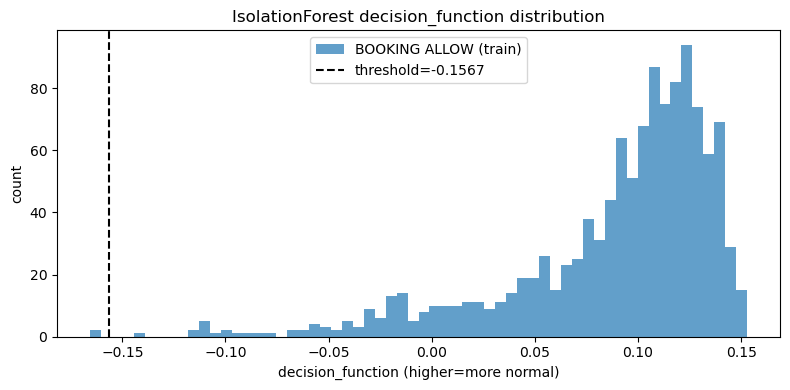

In [10]:
import matplotlib.pyplot as plt

bins = 60
plt.figure(figsize=(8, 4))
plt.hist(scores_human, bins=bins, alpha=0.7, label="BOOKING ALLOW (train)")
if len(scores_macro):
    plt.hist(scores_macro, bins=bins, alpha=0.6, label="BOOKING BLOCK (eval)")
plt.axvline(threshold, color="black", linestyle="--", label=f"threshold={threshold:.4f}")
plt.title("IsolationForest decision_function distribution")
plt.xlabel("decision_function (higher=more normal)")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Save artifacts
save_dir = Path(args.MODEL_SAVE_DIR).expanduser().resolve()
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "model.joblib"
meta_path = save_dir / "meta.json"
features_path = save_dir / "input_features.json"

joblib.dump(pipe, model_path)

meta = {
    "model_name": f"{args.RUN_VERSION}_booking",
    "run_version": args.RUN_VERSION,
    "model_type": "IsolationForest(Pipeline: median-impute + IF)",
    "target_type": "booking",
    "trained_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
    "feature_schema_version": "30_v3",
    "n_features": len(FEATURES_30),
    "feature_names": FEATURES_30,
    "training_filter": {"type": target_type, "label": train_label},
    "threshold": {
        "kind": "decision_function_quantile",
        "target_fp_rate_on_train": float(args.TARGET_FP_RATE),
        "decision_function_threshold": float(threshold),
        "decision_rule": "flag as anomaly when decision_function < threshold",
    },
    "dataset_summary": {
        "jsonl_files": [str(p) for p in jsonl_paths],
        "booking_total": int(len(df_booking)),
        "booking_allow_train": int(len(df_human)),
        "booking_block_eval": int(len(df_macro)),
        "realized_fp_rate_on_train": float(realized_fp),
    },
    "model_params": pipe.named_steps["isoforest"].get_params(),
}
meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
features_path.write_text(json.dumps(FEATURES_30, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

print("saved:")
print(model_path)
print(meta_path)
print(features_path)

saved:
C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\train\model_joblib\isoforest_booking_v1\booking\model.joblib
C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\train\model_joblib\isoforest_booking_v1\booking\meta.json
C:\Users\SSAFY\Desktop\ws\free\develop-ai\S14P31A203\services\ai\train\model_joblib\isoforest_booking_v1\booking\input_features.json
